# Model 1 — Forecast Bias-Correction: In-Sample & Out-of-Sample Performance

In [1]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt

import evaluation

df_train = pd.read_parquet('checkpoints/model1_preds_train.parquet')
df_test = pd.read_parquet('checkpoints/model1_preds_test.parquet')

print(f'Train set: {len(df_train)} rows, {df_train.date.min().date()} to {df_train.date.max().date()}')
print(f'Test set:  {len(df_test)} rows, {df_test.date.min().date()} to {df_test.date.max().date()}')

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


Train set: 16739 rows, 2022-01-01 to 2024-04-16
Test set:  7300 rows, 2025-04-17 to 2026-04-16


## Overall Metrics: In-Sample (Train 2022-2024) vs Out-of-Sample (Test 2026)

In [2]:
train_metrics = evaluation.compute_metrics(df_train['y_true'].values, df_train['mu'].values)
test_metrics = evaluation.compute_metrics(df_test['y_true'].values, df_test['mu'].values)

metrics_df = pd.DataFrame(
    [train_metrics, test_metrics],
    index=['In-Sample (Train 2022-2024)', 'Out-of-Sample (Test 2026)']
)
metrics_df.round(4)

,mae,rmse,bias,r2,corr,n
In-Sample (Train 2022-2024),1.0368,1.4246,-0.0737,0.9943,0.9972,16739
Out-of-Sample (Test 2026),1.2602,1.6857,0.0363,0.9916,0.9958,7300


## Per-City Metrics (Out-of-Sample Test Set)

In [3]:
city_metrics = evaluation.metrics_by_city(df_test, y_true_col='y_true', y_pred_col='mu')
city_metrics.round(4)

,mae,rmse,bias,r2,corr,n,city,ticker
12,0.7361,0.9422,-0.4481,0.9966,0.9987,365,Las Vegas,KXHIGHTLV
16,0.7878,0.9860,-0.1095,0.9950,0.9979,365,Phoenix,KXHIGHTPHX
15,0.9059,1.1595,-0.1195,0.9947,0.9974,365,Oklahoma City,KXHIGHTOKC
9,1.0158,1.3280,0.2542,0.9914,0.9959,365,Dallas,KXHIGHTDAL
13,1.0230,1.3343,-0.2655,0.9968,0.9985,365,Minneapolis,KXHIGHTMIN
7,1.0428,1.3370,-0.2858,0.9912,0.9959,365,Atlanta,KXHIGHTATL
14,1.1218,1.4073,-0.4250,0.9864,0.9941,365,New Orleans,KXHIGHTNOLA
0,1.1409,1.4550,-0.7293,0.9870,0.9951,365,Austin,KXHIGHAUS
17,1.1417,1.5276,0.4963,0.9842,0.9933,365,San Antonio,KXHIGHTSATX
6,1.1578,1.4574,-0.6299,0.9944,0.9980,365,Philadelphia,KXHIGHPHIL


## NN vs NWP Forecast Comparison (Test Set)

In [4]:
import numpy as np
import data_fetch
import config as cfg

nws = data_fetch.load_nws_daily()
nws["date"] = pd.to_datetime(nws["date"])
forecasts = data_fetch.load_forecasts()
forecasts["date"] = pd.to_datetime(forecasts["date"])
merged = nws.merge(forecasts, on=["date", "ticker"], how="inner")

fcst_cols = [c for c in merged.columns if c.startswith("fcst_")]
merged["fcst_ensemble_mean"] = merged[fcst_cols].mean(axis=1)

test = merged[(merged["date"] >= pd.Timestamp(cfg.TEST_START)) & (merged["date"] <= pd.Timestamp(cfg.TEST_END))]

nwp_display = {
    "fcst_gfs_global": "GFS", "fcst_ecmwf_ifs025": "ECMWF",
    "fcst_icon_seamless": "ICON", "fcst_gem_seamless": "GEM",
    "fcst_jma_seamless": "JMA", "fcst_ncep_hrrr_conus": "HRRR",
    "fcst_ensemble_mean": "NWP Ens. Mean",
}

rows = []
for col in fcst_cols + ["fcst_ensemble_mean"]:
    mask = test[col].notna()
    y_true = test.loc[mask, "nws_high"].values
    y_pred = test.loc[mask, col].values
    err = np.abs(y_pred - y_true)
    rows.append({
        "Model": nwp_display.get(col, col),
        "MAE (F)": np.mean(err),
        "RMSE (F)": np.sqrt(np.mean((y_pred - y_true)**2)),
        "Within 1F (%)": np.mean(err <= 1.0) * 100,
        "Within 2F (%)": np.mean(err <= 2.0) * 100,
    })

nn_err = np.abs(df_test["mu"].values - df_test["y_true"].values)
nn_resid = df_test["mu"].values - df_test["y_true"].values
rows.append({
    "Model": "NN Bias-Correction",
    "MAE (F)": np.mean(nn_err),
    "RMSE (F)": np.sqrt(np.mean(nn_resid**2)),
    "Within 1F (%)": np.mean(nn_err <= 1.0) * 100,
    "Within 2F (%)": np.mean(nn_err <= 2.0) * 100,
})

comparison = pd.DataFrame(rows).sort_values("MAE (F)").reset_index(drop=True)
comparison.round(2)

,Model,MAE (F),RMSE (F),Within 1F (%),Within 2F (%)
0,NN Bias-Correction,1.26,1.69,50.81,80.82
1,HRRR,2.07,2.98,37.92,63.52
2,NWP Ens. Mean,2.28,2.94,26.30,52.36
3,GFS,2.37,3.13,29.49,53.79
4,ICON,2.42,3.46,30.60,55.56
5,GEM,2.52,3.55,31.44,54.25
6,ECMWF,2.85,3.64,21.63,42.14
7,JMA,4.34,5.40,12.00,25.44


## Calibration Check (Out-of-Sample Test Set)

,target_coverage,actual_coverage
0,0.50,0.4530
1,0.68,0.6230
2,0.80,0.7416
3,0.90,0.8496
4,0.95,0.9107
5,0.99,0.9664


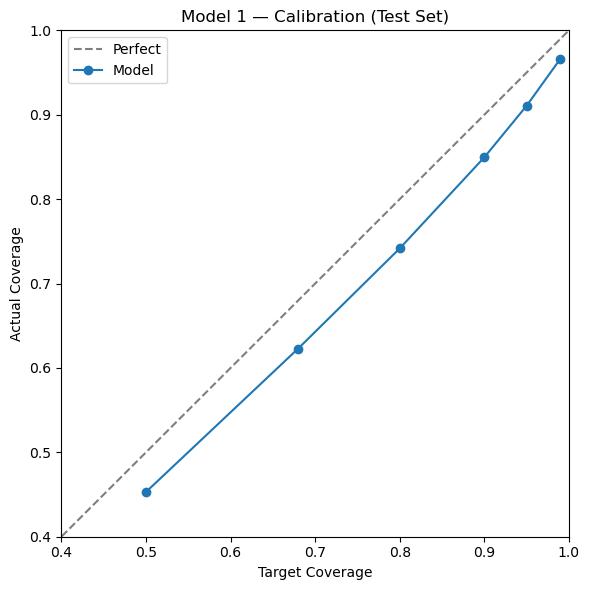

In [5]:
cal_df = evaluation.calibration_check(df_test['y_true'].values, df_test['mu'].values, df_test['sigma'].values)
display(cal_df.round(4))

fig = evaluation.plot_calibration(cal_df, title='Model 1 — Calibration (Test Set)')
plt.show()

## Residuals Histogram + Q-Q Plot

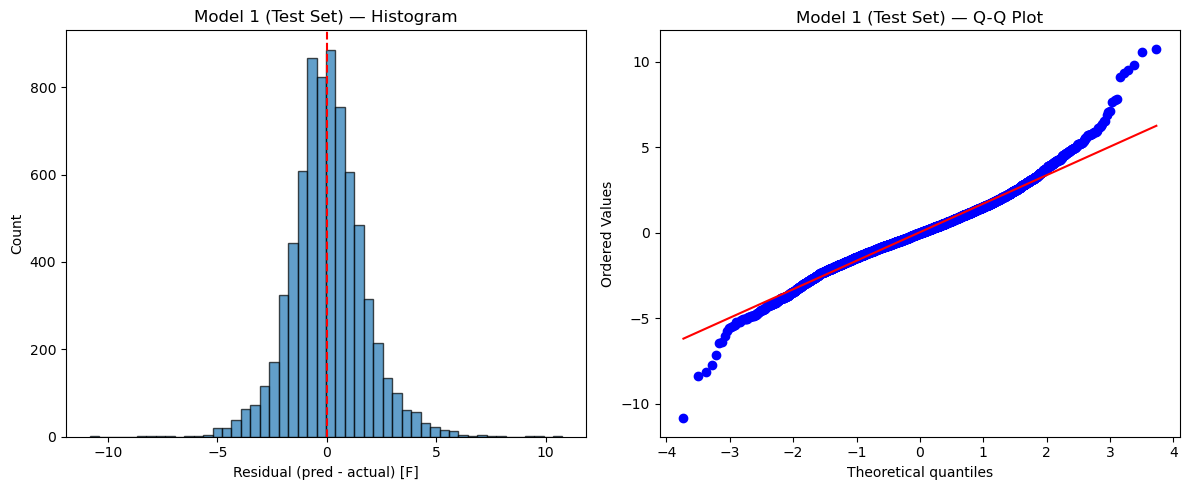

In [6]:
fig = evaluation.plot_residuals(df_test['y_true'].values, df_test['mu'].values, title='Model 1 (Test Set)')
plt.show()

## Time Series — NY, Phoenix, Miami

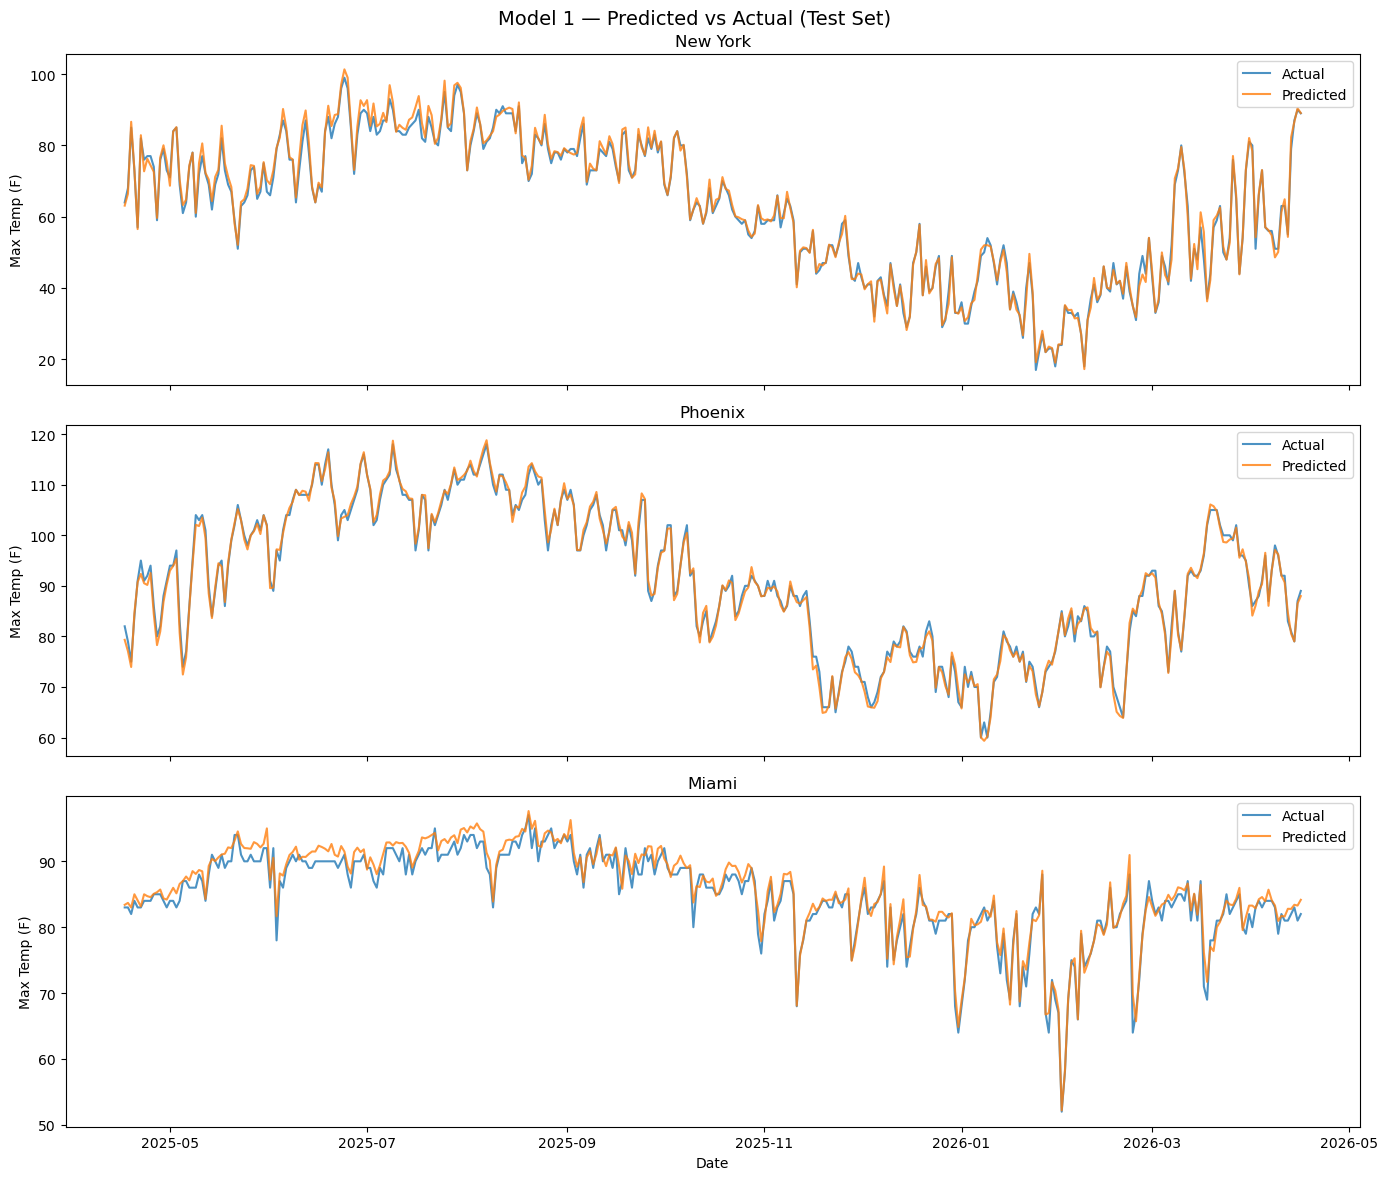

In [7]:
fig = evaluation.plot_timeseries(
    df_test, y_true_col='y_true', y_pred_col='mu',
    cities=['KXHIGHNY', 'KXHIGHTPHX', 'KXHIGHMIA'],
    title='Model 1 — Predicted vs Actual (Test Set)'
)
plt.show()

## MAE Heatmap by City and Month

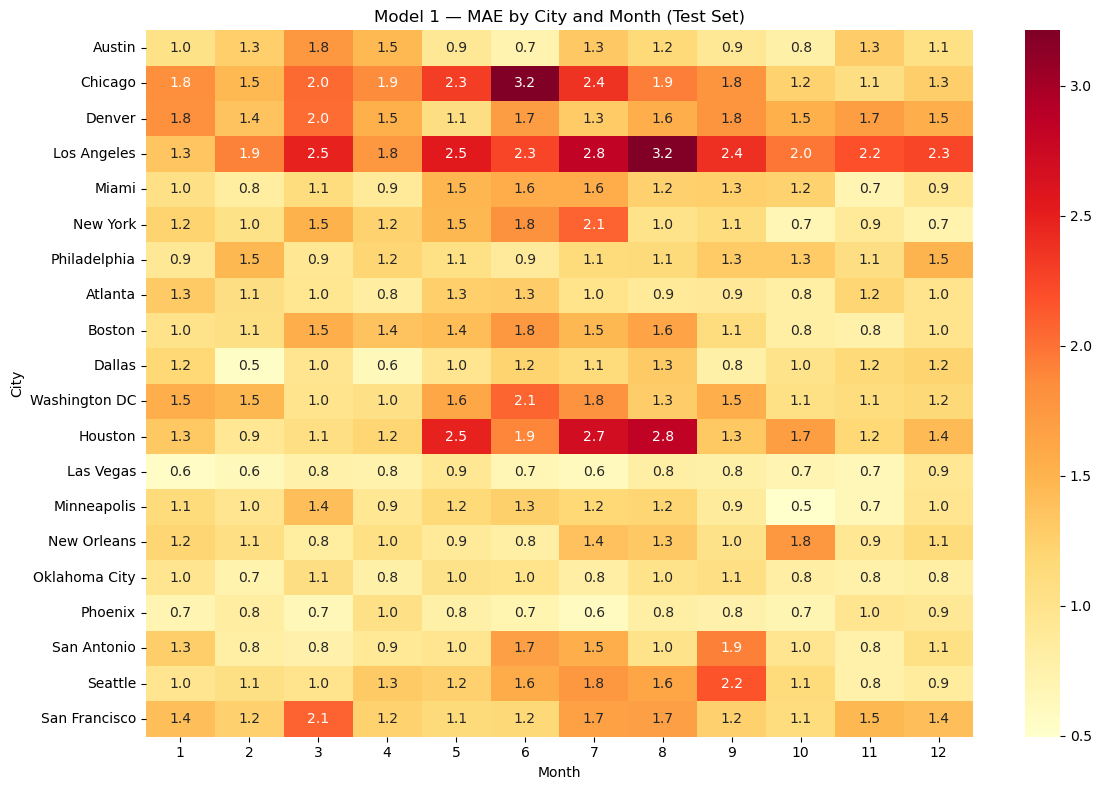

In [8]:
fig = evaluation.plot_mae_heatmap(
    df_test, y_true_col='y_true', y_pred_col='mu',
    title='Model 1 — MAE by City and Month (Test Set)'
)
plt.show()